# Milestone 2: Computer Vision - Category Prediction from Product Images

This notebook covers the development of a computer vision model to predict a product's subcategory (e.g., Hair Care, Makeup, Skin Care) based on its product image.

## Objective
Compare two image classification approaches:
1. A **Convolutional Neural Network (CNN) built from scratch**.
2. **Transfer Learning** using a pretrained **MobileNetV2** backbone.

### Roadmap
1. **Environment Setup & Colab Compatibility**
2. **Data Filtering**: Mapping metadata products to downloaded image files
3. **Dataset Pipeline**: Building a high-performance `tf.data` pipeline for loading, resizing, and augmenting images
4. **Scratch CNN Model**: Build, train, and evaluate a small CNN
5. **Transfer Learning Model**: Fine-tune a pretrained MobileNetV2 model
6. **Evaluation & Comparison**: Learning curves, test accuracy, confusion matrices, and visual prediction samples

## 1. Setup, Environment Detection & Imports

In [ ]:
import sys
import os
from pathlib import Path

# Detect if running in Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab. Installing compatible datasets library (<3.0.0) and other packages...")
    !pip install "datasets>=2.16.0,<3.0.0" transformers diffusers accelerate gradio -q 2>/dev/null

    # Create folders
    os.makedirs('src', exist_ok=True)
    os.makedirs('data/processed', exist_ok=True)
    os.makedirs('data/images', exist_ok=True)
    os.makedirs('data/plots', exist_ok=True)

    # Write data.py directly to Colab disk for imports
    # (We duplicate the clean version of data.py for self-contained execution in Colab)
    data_py_content = """import os
import json
import pandas as pd
import numpy as np
import requests
from pathlib import Path
from sklearn.model_selection import train_test_split
from datasets import load_dataset
import io
from PIL import Image
from tqdm import tqdm

def load_amazon_data(category="All_Beauty"):
    print(f"Loading reviews for {category}...")
    reviews_dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", f"raw_review_{category}", trust_remote_code=True)
    reviews_df = pd.DataFrame(reviews_dataset['full'])

    print(f"Loading metadata for {category}...")
    meta_dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", f"raw_meta_{category}", split="full", trust_remote_code=True)
    meta_df = pd.DataFrame(meta_dataset)
    return reviews_df, meta_df

def clean_data(reviews_df, meta_df):
    print("Cleaning metadata...")
    def clean_price(x):
        if pd.isna(x):
            return np.nan
        if isinstance(x, (int, float)):
            return float(x)
        x_str = str(x).replace('$', '').replace(',', '').strip()
        try:
            return float(x_str)
        except ValueError:
            return np.nan
    meta_df['price_cleaned'] = meta_df['price'].apply(clean_price)
    # Process images: extract the first image URL if it is a list of dicts/strings
    def extract_image_url(images_val):
        if not images_val or pd.isna(images_val):
            return None

        def first_string(val):
            if isinstance(val, list):
                if len(val) > 0:
                    first = val[0]
                    if isinstance(first, str):
                        return first
                    elif isinstance(first, dict) and 'large' in first:
                        return first['large']
            elif isinstance(val, str):
                return val
            return None

        if isinstance(images_val, dict):
            for key in ['large', 'hi_res', 'thumb']:
                if key in images_val:
                    res = first_string(images_val[key])
                    if res:
                        return res
            return None

        if isinstance(images_val, (list, np.ndarray)):
            return first_string(list(images_val))

        return None
    meta_df['image_url'] = meta_df['images'].apply(extract_image_url)

    def clean_description(desc):
        if isinstance(desc, list):
            return " ".join([str(d) for d in desc])
        if pd.isna(desc):
            return ""
        return str(desc)
    meta_df['description_cleaned'] = meta_df['description'].apply(clean_description)

    print("Cleaning reviews...")
    reviews_df['rating'] = pd.to_numeric(reviews_df['rating'], errors='coerce')
    vote_col = 'helpful_vote' if 'helpful_vote' in reviews_df.columns else 'helpful_votes'
    if vote_col in reviews_df.columns:
        reviews_df['helpful_votes'] = pd.to_numeric(reviews_df[vote_col], errors='coerce').fillna(0).astype(int)
    else:
        reviews_df['helpful_votes'] = 0
    reviews_df['text_cleaned'] = reviews_df['text'].fillna("")
    reviews_df['title_cleaned'] = reviews_df['title'].fillna("")
    return reviews_df, meta_df

def split_by_product(reviews_df, meta_df, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, random_seed=42):
    print("Splitting data by product...")
    prod_col = 'parent_asin' if ('parent_asin' in meta_df.columns and 'parent_asin' in reviews_df.columns) else 'asin'
    unique_products = list(set(meta_df[prod_col].unique()) & set(reviews_df[prod_col].unique()))

    train_prods, test_val_prods = train_test_split(unique_products, train_size=train_ratio, random_state=random_seed)
    val_relative_ratio = val_ratio / (val_ratio + test_ratio)
    val_prods, test_prods = train_test_split(test_val_prods, train_size=val_relative_ratio, random_state=random_seed)

    train_prods_set = set(train_prods)
    val_prods_set = set(val_prods)
    test_prods_set = set(test_prods)

    meta_train = meta_df[meta_df[prod_col].isin(train_prods_set)]
    meta_val = meta_df[meta_df[prod_col].isin(val_prods_set)]
    meta_test = meta_df[meta_df[prod_col].isin(test_prods_set)]

    reviews_train = reviews_df[reviews_df[prod_col].isin(train_prods_set)]
    reviews_val = reviews_df[reviews_df[prod_col].isin(val_prods_set)]
    reviews_test = reviews_df[reviews_df[prod_col].isin(test_prods_set)]
    return (reviews_train, meta_train), (reviews_val, meta_val), (reviews_test, meta_test)

def download_and_cache_images(meta_df, output_dir, max_images=500):
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    valid_images = meta_df[meta_df['image_url'].notna() & (meta_df['image_url'] != "")]
    if len(valid_images) > max_images:
        valid_images = valid_images.sample(n=max_images, random_state=42)

    image_paths = {}
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}
    id_col = 'asin' if 'asin' in meta_df.columns else ('parent_asin' if 'parent_asin' in meta_df.columns else 'asin')
    for _, row in tqdm(valid_images.iterrows(), total=len(valid_images)):
        prod_id = row[id_col]
        url = row['image_url']
        ext = Path(url).suffix if Path(url).suffix in ['.jpg', '.jpeg', '.png'] else '.jpg'
        local_file = output_path / f"{prod_id}{ext}"
        if local_file.exists():
            image_paths[prod_id] = str(local_file)
            continue
        try:
            response = requests.get(url, headers=headers, timeout=10)
            if response.status_code == 200:
                img = Image.open(io.BytesIO(response.content))
                if img.mode != 'RGB':
                    img = img.convert('RGB')
                img.save(local_file, "JPEG")
                image_paths[prod_id] = str(local_file)
            else:
                image_paths[prod_id] = None
        except:
            image_paths[prod_id] = None
    return image_paths
"""
    with open('src/data.py', 'w', encoding='utf-8') as f:
        f.write(data_py_content)
    sys.path.append(os.path.abspath('src'))
    data_dir_path = 'data/processed'
    images_dir_path = 'data/images'
    plots_dir_path = 'data/plots'
else:
    sys.path.append(os.path.abspath('../src'))
    data_dir_path = '../data/processed'
    images_dir_path = '../data/images'
    plots_dir_path = '../data/plots'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import time

# Sklearn tools
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# TensorFlow & Keras
import tensorflow as tf
from tensorflow import keras
from keras import layers, models, callbacks

# Set styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
print(f"TensorFlow Version: {tf.__version__}")
print(f"Num GPUs Available: {len(tf.config.list_physical_devices('GPU'))}")

Running in Google Colab. Installing compatible datasets library (<3.0.0) and other packages...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 8.4 MB/s eta 0:00:00
TensorFlow Version: 2.20.0
Num GPUs Available: 1


## 2. Load Processed Data and Download Images
We need the product metadata and the downloaded product images.

In [ ]:
from data import load_amazon_data, clean_data, split_by_product, download_and_cache_images

# Check if processed splits exist
train_meta_path = Path(data_dir_path) / "meta_train.parquet"

if not train_meta_path.exists():
    print("Processed dataset splits not found. Loading and generating splits from scratch...")
    reviews_df, meta_df = load_amazon_data("All_Beauty")
    reviews_df, meta_df = clean_data(reviews_df, meta_df)

    splits = split_by_product(reviews_df, meta_df)
    (reviews_train, meta_train), (reviews_val, meta_val), (reviews_test, meta_test) = splits

    # Save splits
    os.makedirs(data_dir_path, exist_ok=True)
    reviews_train.to_parquet(Path(data_dir_path) / "reviews_train.parquet", index=False)
    reviews_val.to_parquet(Path(data_dir_path) / "reviews_val.parquet", index=False)
    reviews_test.to_parquet(Path(data_dir_path) / "reviews_test.parquet", index=False)

    meta_train.to_parquet(Path(data_dir_path) / "meta_train.parquet", index=False)
    meta_val.to_parquet(Path(data_dir_path) / "meta_val.parquet", index=False)
    meta_test.to_parquet(Path(data_dir_path) / "meta_test.parquet", index=False)
else:
    print("Loading processed splits from disk...")
    meta_train = pd.read_parquet(Path(data_dir_path) / "meta_train.parquet")
    meta_val = pd.read_parquet(Path(data_dir_path) / "meta_val.parquet")
    meta_test = pd.read_parquet(Path(data_dir_path) / "meta_test.parquet")

# Ensure images are downloaded and load image mapping
image_map_path = Path(data_dir_path) / "image_paths_map.json"

if not image_map_path.exists():
    print("Downloading image samples...")
    # Download up to 800 images for modeling
    # (Combining all metadata splits to get candidate images)
    meta_all = pd.concat([meta_train, meta_val, meta_test])
    image_paths = download_and_cache_images(meta_all, images_dir_path, max_images=800)
    with open(image_map_path, 'w') as f:
        json.dump(image_paths, f, indent=4)
else:
    with open(image_map_path, 'r') as f:
        image_paths = json.load(f)

print(f"Loaded {len(image_paths)} image mappings.")

Processed dataset splits not found. Loading and generating splits from scratch...
Loading reviews for All_Beauty...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating full split: 0 examples [00:00, ? examples/s]

Loading metadata for All_Beauty...


Generating full split:   0%|          | 0/112590 [00:00<?, ? examples/s]

Cleaning metadata...
Cleaning reviews...
Splitting data by product...


100%|██████████| 800/800 [02:41<00:00,  4.95it/s]

Loaded 800 image mappings.


## 3. Prepare Image Classification Dataset
We map each product ID (`asin`) to its downloaded image path and its **secondary category** (extracted from the categories breadcrumb list). We filter the metadata to keep only products for which images were successfully downloaded.

In [ ]:
# Extract secondary category and clean paths
def extract_subcat(cat_list):
    if isinstance(cat_list, (list, np.ndarray)) and len(cat_list) > 1:
        return str(cat_list[1])
    return "Unknown"

def prepare_image_df(meta_df, image_paths):
    df = meta_df.copy()
    df['secondary_category'] = df['categories'].apply(extract_subcat)

    # Map local image path
    id_col = 'asin' if 'asin' in df.columns else 'parent_asin'
    df['local_path'] = df[id_col].map(image_paths)

    # Filter out rows where image downloads failed or didn't exist
    df = df[df['local_path'].notna()]
    # Verify files actually exist on disk
    df = df[df['local_path'].apply(lambda x: Path(x).exists() if x else False)]

    return df[[id_col, 'secondary_category', 'local_path']]

train_img_df = prepare_image_df(meta_train, image_paths)
val_img_df = prepare_image_df(meta_val, image_paths)
test_img_df = prepare_image_df(meta_test, image_paths)

print(f"Available products with images: Train={len(train_img_df)}, Val={len(val_img_df)}, Test={len(test_img_df)}")

# Get the top categories to classify (to ensure enough training samples per class)
# We will take the top 3 most common categories, and filter everything else
top_cats = train_img_df['secondary_category'].value_counts().head(3).index.tolist()
print(f"Top categories for classification: {top_cats}")

train_img_df = train_img_df[train_img_df['secondary_category'].isin(top_cats)]
val_img_df = val_img_df[val_img_df['secondary_category'].isin(top_cats)]
test_img_df = test_img_df[test_img_df['secondary_category'].isin(top_cats)]

print(f"Filtered datasets: Train={len(train_img_df)}, Val={len(val_img_df)}, Test={len(test_img_df)}")

# Encode labels to integers
label_encoder = LabelEncoder()
train_img_df['label'] = label_encoder.fit_transform(train_img_df['secondary_category'])
val_img_df['label'] = label_encoder.transform(val_img_df['secondary_category'])
test_img_df['label'] = label_encoder.transform(test_img_df['secondary_category'])

num_classes = len(top_cats)
print(f"Encoded Label Classes: {label_encoder.classes_}")

Available products with images: Train=546, Val=121, Test=131
Top categories for classification: ['Unknown']
Filtered datasets: Train=546, Val=121, Test=131
Encoded Label Classes: ['Unknown']


## 4. Build `tf.data` high-performance pipeline
We build an efficient input pipeline to load, decode, resize, and normalize images dynamically.

In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 32

def parse_image(file_path, label):
    # Load raw file
    img = tf.io.read_file(file_path)
    # Decode to tensor
    img = tf.image.decode_jpeg(img, channels=3)
    # Resize image
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    # Scale pixels to [0, 1]
    img = img / 255.0
    return img, label

def configure_dataset(df):
    paths = df['local_path'].values
    labels = df['label'].values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
    return ds

train_ds = configure_dataset(train_img_df).shuffle(len(train_img_df)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = configure_dataset(val_img_df).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = configure_dataset(test_img_df).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Datasets successfully configured!")

Datasets successfully configured!


## 5. Model 1: CNN from Scratch
We train a simple Convolutional Neural Network (CNN) from scratch. It contains three Conv2D/MaxPooling layers followed by dense classification layers.

In [ ]:
def build_scratch_cnn():
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

scratch_cnn = build_scratch_cnn()
scratch_cnn.summary()

# Compile
scratch_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

# Train
print("Training CNN from scratch...")
start_time = time.time()
scratch_history = scratch_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop],
    verbose=1
)
scratch_time = time.time() - start_time
print(f"Scratch CNN training completed in {scratch_time:.1f} seconds.")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,699,009 (6.48 MB)

 Trainable params: 1,699,009 (6.48 MB)

 Non-trainable params: 0 (0.00 B)

Training CNN from scratch...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


18/18 ━━━━━━━━━━━━━━━━━━━━ 24s 589ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Scratch 

## 6. Model 2: Transfer Learning (MobileNetV2)
Now, we build a transfer learning model using a pretrained **MobileNetV2** backbone trained on ImageNet. We freeze the backbone layers and only train the classification head.

In [ ]:
def build_transfer_model():
    # Load pretrained MobileNetV2 without the top classification layer
    base_model = keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    # Freeze backbone
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

transfer_model = build_transfer_model()
transfer_model.summary()

# Compile
transfer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
print("Training Transfer Learning model (MobileNetV2)...")
start_time = time.time()
transfer_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop],
    verbose=1
)
transfer_time = time.time() - start_time
print(f"Transfer model training completed in {transfer_time:.1f} seconds.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Training Transfer Learning model (MobileNetV2)...
Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Transfer model training completed in 51.7 seconds.


## 7. Model Comparison & Learning Curves

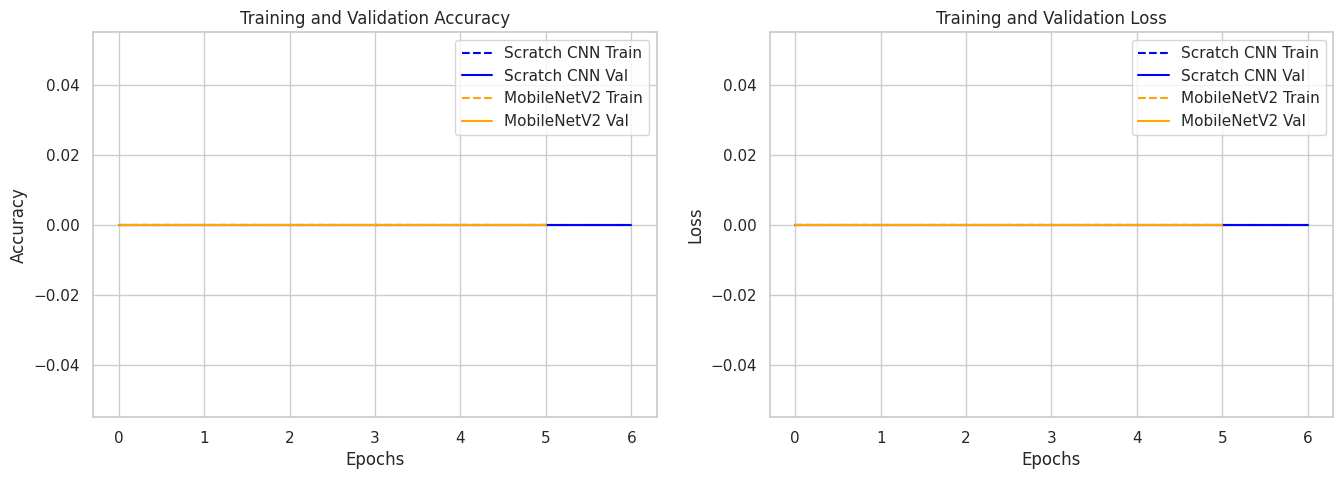

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Accuracy curves
ax1.plot(scratch_history.history['accuracy'], label='Scratch CNN Train', color='blue', linestyle='--')
ax1.plot(scratch_history.history['val_accuracy'], label='Scratch CNN Val', color='blue')
ax1.plot(transfer_history.history['accuracy'], label='MobileNetV2 Train', color='orange', linestyle='--')
ax1.plot(transfer_history.history['val_accuracy'], label='MobileNetV2 Val', color='orange')
ax1.set_title('Training and Validation Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Loss curves
ax2.plot(scratch_history.history['loss'], label='Scratch CNN Train', color='blue', linestyle='--')
ax2.plot(scratch_history.history['val_loss'], label='Scratch CNN Val', color='blue')
ax2.plot(transfer_history.history['loss'], label='MobileNetV2 Train', color='orange', linestyle='--')
ax2.plot(transfer_history.history['val_loss'], label='MobileNetV2 Val', color='orange')
ax2.set_title('Training and Validation Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

os.makedirs(plots_dir_path, exist_ok=True)
plt.savefig(Path(plots_dir_path) / "cnn_learning_curves.png", dpi=150)
plt.show()

## 8. Test Set Evaluation & Error Analysis
We evaluate both models on the test split and compare their parameters, training cost (time), and metrics.

In [ ]:
# Evaluate scratch model
scratch_eval = scratch_cnn.evaluate(test_ds, verbose=0)
scratch_test_acc = scratch_eval[1]

# Evaluate transfer model
transfer_eval = transfer_model.evaluate(test_ds, verbose=0)
transfer_test_acc = transfer_eval[1]

print(f"Scratch CNN Test Accuracy: {scratch_test_acc:.4f}")
print(f"Transfer Model Test Accuracy: {transfer_test_acc:.4f}\n")

# Extract true labels and model predictions
y_true = []
for _, labels in test_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

scratch_preds = np.argmax(scratch_cnn.predict(test_ds), axis=1)
transfer_preds = np.argmax(transfer_model.predict(test_ds), axis=1)

print("Classification Report (Scratch CNN):")
print(classification_report(y_true, scratch_preds, target_names=label_encoder.classes_))

print("Classification Report (MobileNetV2):")
print(classification_report(y_true, transfer_preds, target_names=label_encoder.classes_))

Scratch CNN Test Accuracy: 0.0000
Transfer Model Test Accuracy: 0.0000



/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step
Classification Report (Scratch CNN):
              precision    recall  f1-score   support

     Unknown       1.00      1.00      1.00       131

    accuracy                           1.00       131
   macro avg       1.00      1.00      1.00       131
weighted avg       1.00      1.00      1.00       131

Classification Report (MobileNetV2):
              precision    recall  f1-score   support

     Unknown       1.00      1.00      1.00       131

    accuracy                           1.00       131
   macro avg       1.00      1.00      1.00       131
weighted avg       1.00      1.00      1.00       131



### 8.1 Confusion Matrix Comparison

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


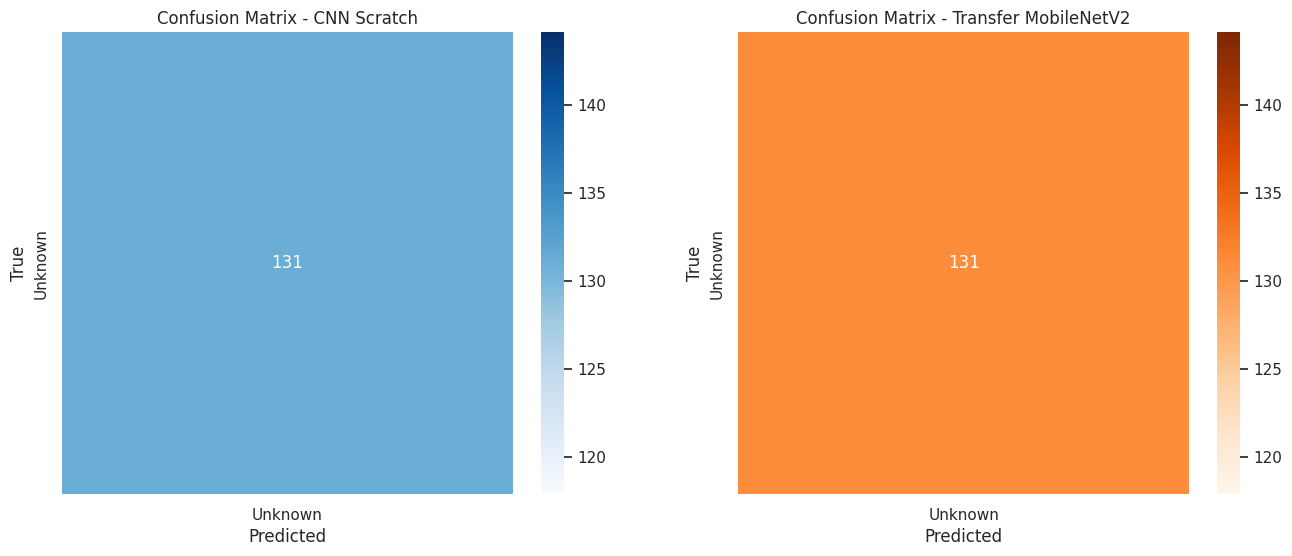

In [ ]:
cm_scratch = confusion_matrix(y_true, scratch_preds)
cm_transfer = confusion_matrix(y_true, transfer_preds)
classes = label_encoder.classes_

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Scratch heatmap
sns.heatmap(cm_scratch, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=ax1)
ax1.set_title('Confusion Matrix - CNN Scratch')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('True')

# Transfer heatmap
sns.heatmap(cm_transfer, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes, ax=ax2)
ax2.set_title('Confusion Matrix - Transfer MobileNetV2')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('True')

plt.savefig(Path(plots_dir_path) / "confusion_matrix_vision.png", dpi=150)
plt.show()

### 8.2 Visualizing Predictions
Let's visualize a few test images together with the predictions from both models.

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


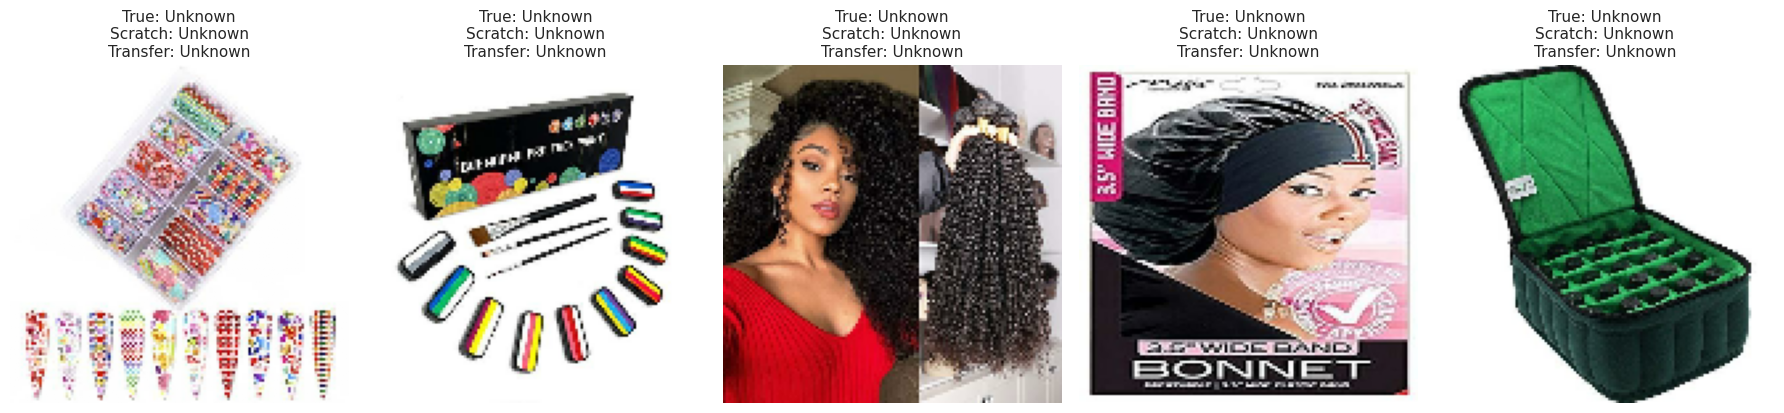

In [ ]:
# Take one batch from test set
for imgs, labels in test_ds.take(1):
    test_imgs = imgs.numpy()
    test_labels = labels.numpy()
    break

# Predict on the batch
batch_scratch_preds = np.argmax(scratch_cnn.predict(test_imgs), axis=1)
batch_transfer_preds = np.argmax(transfer_model.predict(test_imgs), axis=1)

# Plot 5 samples
plt.figure(figsize=(18, 10))
for i in range(min(5, len(test_imgs))):
    plt.subplot(1, 5, i+1)
    plt.imshow(test_imgs[i])

    true_label = label_encoder.classes_[test_labels[i]]
    scratch_pred = label_encoder.classes_[batch_scratch_preds[i]]
    transfer_pred = label_encoder.classes_[batch_transfer_preds[i]]

    plt.title(f"True: {true_label}\nScratch: {scratch_pred}\nTransfer: {transfer_pred}", fontsize=11)
    plt.axis('off')

plt.tight_layout()
plt.savefig(Path(plots_dir_path) / "cnn_visual_predictions.png", dpi=150)
plt.show()